# TV under-reach with a true S-curve: Meridian's fixed slope_m=1 assumption

**Objective.** Every notebook in this series -- including the real-data
and roi-shape-coupling variants -- hardcodes each channel's Hill
`slope_m` at exactly `1.0` in the DGP (`data_simulator.py`'s
`simulate_adstock_hill_params()` used to draw `self.slope_m = tf.ones(...)`
unconditionally). `Hill(x) = x/(x+ec)` at `slope=1` is purely concave:
marginal value is *highest* right at `x=0` and monotonically falls as
exposure grows. There is no "barely shown once -> no response" regime --
even a sliver of exposure gets the maximum marginal value per exposure,
immediately.

Real response curves plausibly aren't always like that. Robyn's saturation
transform (https://facebookexperimental.github.io/Robyn/docs/analysts-
guide-to-MMM) is `x^alpha / (x^alpha + gamma^alpha)` -- *exactly* Meridian's
`Hill(x) = x^slope / (x^slope + ec^slope)`. Robyn's `alpha` is Meridian's
`slope_m` (not to be confused with this simulator's own `alpha_m`, which is
adstock retention -- Robyn's `theta`). `alpha/slope > 1` gives a genuine
S-curve: near-zero response *and* near-zero marginal value close to `x=0`,
before marginal value rises, peaks, then decays -- a real "needs a
threshold of exposure before eliciting any response" regime, which a
concave curve structurally cannot represent.

This matters more than an ordinary prior-misspecification story, because
Meridian's own default `slope_m` prior for plain (non-RF) media channels
is a hard `tfd.Deterministic(1.0)` (`meridian/model/prior_distribution.
py`) -- not merely uninformative, but literally unfittable unless a
notebook explicitly overrides it (Meridian even warns when you do:
*"changing the prior for slope_m may lead to convex Hill curves... may
lead to poor MCMC convergence"*). So a channel given a true `slope_m != 1`
is one every model in this series so far was structurally incapable of
representing, no matter how good its `ec_m`/`alpha_m` priors were.

`SimulationConfig.slope_range` (`data_simulator.py`) makes `slope_m`
configurable per channel, defaulting to `(1.0, 1.0)` everywhere -- an exact
no-op reproducing every other notebook's fixed-concave DGP. This notebook
gives **TV** a true `slope_m=2.0` (a clear, literature-plausible S-curve --
Robyn's own `alpha` search space is commonly bounded in roughly the 0.5-3
range) -- tying into the existing "TV under-delivered" story: if TV's true
response also has a real exposure threshold, its current very-low execution
is worth even less at the margin than a concave curve implies, not more.

**How to read this notebook:**
- Section 1 builds the real-data-scaled scenario with TV's true `slope_m`
  fixed at 2.0, reports true `ec_m`/`alpha_m`/`slope_m`/`roi_m`, and plots
  TV's true response curve against the concave curve Meridian assumes by
  default.
- Section 2 fits `default` and `ec_alpha_only` (both stuck at Meridian's
  hardcoded `slope_m=1`) against `ec_alpha_slope_only` (which also informs
  `slope_m`, the only variant capable of representing the true S-curve at
  all) and compares recovery via `model_utils.build_comparison_table`.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
from model_utils import build_real_augmented_input
from model_utils import ceiling_fraction_at_median
from model_utils import filter_param_summary
from model_utils import hill_value

## 1. Real-data-scaled TV/Display/Social, with TV's true slope_m fixed at 2.0

Same real-data sourcing, targets, and knots-matching as
`tv-test-under-real-demo-data-coefficient-prior.ipynb` -- the only change
is `slope_range`, giving TV a true S-curve while Display/Social stay at
Meridian's usual concave `slope=1`. `roi_ec_elasticity`/
`roi_alpha_elasticity` are left at their `0.0` default (independent
`target_roi`), to isolate the slope-mismatch effect on its own rather than
compounding it with the roi-shape coupling from the companion notebook.

I0000 00:00:1785190510.400426 8184304 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3826793   0.26670453]


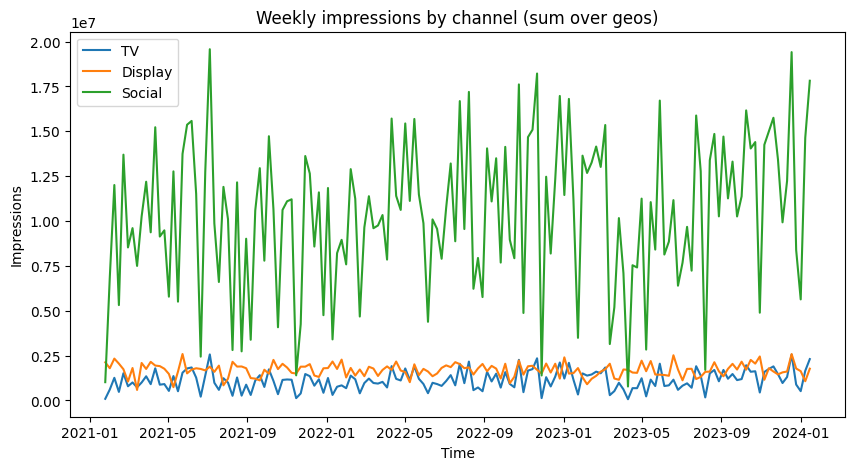

In [2]:
SLOPE_MISMATCH_CONFIG_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        'TV': (1, 2),
        'Display': (1, 5),
        'Social': (7.0, 8.0),
    },
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'n_knots_mu_t': 8,
    # The new part: TV gets a genuine S-curve (slope=2.0); Display/Social
    # stay at Meridian's usual concave default (slope=1.0).
    'slope_range': {
        'TV': (2.0, 2.0),
        'Display': (1.0, 1.0),
        'Social': (1.0, 1.0),
    },
}

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)

config = SimulationConfig.from_dict(SLOPE_MISMATCH_CONFIG_OVERRIDES)
sim, data, ground_truth = build_real_augmented_input(
    config,
    real_df,
    rf_source_map={'TV': 'Channel3', 'Social': 'Channel3'},
    plain_source_map={'Display': 'Channel0'},
)
sim.plot_media_time_series()
plt.show()

In [3]:
audience_national_m = sim.audience_national_m.numpy()
mean_reach_frac_m = sim.reach_count_gtm.numpy().mean(axis=(0, 1)) / (
    sim.audience_g_m.numpy().mean(axis=0)
)
mean_frequency_m = sim.frequency_gtm.numpy().mean(axis=(0, 1))
true_ec_m = sim.ec_m.numpy()
true_alpha_m = sim.alpha_m.numpy()
true_slope_m = sim.slope_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m, true_slope_m)

for i, ch in enumerate(config.channel_names):
  print(
      f'{ch}: target audience ~ {audience_national_m[i] / 1e6:.1f}M, '
      f'reaching ~ {mean_reach_frac_m[i] * 100:.1f}% at frequency '
      f'~ {mean_frequency_m[i]:.1f}/week'
  )
print()
print(f'true alpha_m: {true_alpha_m}')
print(f'true ec_m (multiples of current median delivery): {true_ec_m}')
print(f'true slope_m: {true_slope_m}')
print(f'true fraction of ceiling effect captured today:   {true_ceiling_frac}')
print(f'true roi_m: {ground_truth["roi_m"]}')

TV: target audience ~ 6.3M, reaching ~ 10.0% at frequency ~ 1.5/week
Display: target audience ~ 1.1M, reaching ~ 50.0% at frequency ~ 3.0/week
Social: target audience ~ 1.6M, reaching ~ 76.7% at frequency ~ 7.5/week

true alpha_m: [0.53567725 0.07843037 0.25244984]
true ec_m (multiples of current median delivery): [11.069365    1.3826793   0.26670453]
true slope_m: [2. 1. 1.]
true fraction of ceiling effect captured today:   [0.00809515 0.41969556 0.78945005]
true roi_m: [8.000001  5.0000005 2.9999995]


TV's true response curve against the concave curve Meridian assumes by
default (both drawn at TV's true `ec_m`, so the only difference is
`slope`). The vertical line marks TV's current median delivery
(`x=1`, population-scaled units) -- the level Section 1's "fraction of
ceiling effect captured today" diagnostic is evaluated at.

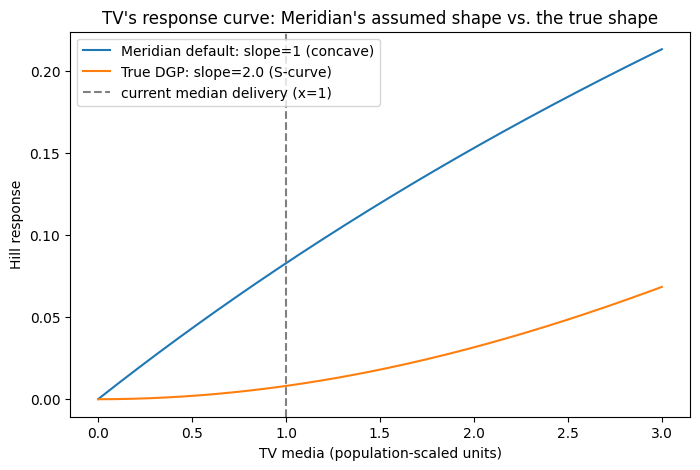

In [4]:
x_grid = np.linspace(0.001, 3, 200)
ec_tv = float(true_ec_m[0])
hill_default_shape = hill_value(x_grid, ec_tv, slope=1.0)[:, 0]
hill_true_shape = hill_value(x_grid, ec_tv, slope=float(true_slope_m[0]))[:, 0]

plt.figure(figsize=(8, 5))
plt.plot(x_grid, hill_default_shape, label='Meridian default: slope=1 (concave)')
plt.plot(
    x_grid,
    hill_true_shape,
    label=f'True DGP: slope={true_slope_m[0]:.1f} (S-curve)',
)
plt.axvline(1.0, linestyle='--', color='gray', label='current median delivery (x=1)')
plt.xlabel('TV media (population-scaled units)')
plt.ylabel('Hill response')
plt.title("TV's response curve: Meridian's assumed shape vs. the true shape")
plt.legend()
plt.show()

## 2. default / ec_alpha_only (stuck at slope=1) vs. ec_alpha_slope_only

`default` and `ec_alpha_only` both use Meridian's hardcoded
`slope_m=Deterministic(1.0)` -- neither can represent TV's true S-curve at
any point during fitting, regardless of how good their `ec_m`/`alpha_m`
priors are. `ec_alpha_slope_only` extends `ec_alpha_only` with
`model_utils.build_slope_prior`, a `LogNormal` prior centered on the true
`slope_m` -- the only variant here capable of representing the true curve
shape at all.

In [5]:
SLOPE_VARIANTS = ['default', 'ec_alpha_only', 'ec_alpha_slope_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
for variant in SLOPE_VARIANTS:
  model_spec = build_model_spec(
      variant, sim, config, media_prior_type='coefficient'
  )
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm

build_comparison_table(fitted_mmms, config, sim, ground_truth, hdi_prob=0.9)

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-27 17:15:39.748953: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-27 17:19:50.050986: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/mode

...

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance /

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance 

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance 

,channel,param,true,default,ec_alpha_only,ec_alpha_slope_only
0,TV,alpha_m,0.536,0.467 (0.46-0.48) ✗,0.478 (0.47-0.49) ✗,0.678 (0.53-0.82) ✓
1,TV,ec_m,11.069,7.897 (7.11-8.73) ✗,16.658 (14.26-18.84) ✗,1.994 (0.15-3.84) ✗
2,TV,roi_m,8.000,19.013 (18.53-19.54) ✗,17.780 (17.33-18.27) ✗,126.160 (98.88-153.44) ✗
3,Display,alpha_m,0.078,0.182 (0.03-0.31) ✓,0.097 (0.00-0.18) ✓,0.309 (0.23-0.39) ✗
4,Display,ec_m,1.383,0.317 (0.10-0.83) ✗,1.405 (1.17-1.63) ✓,2.205 (0.82-3.59) ✓
5,Display,roi_m,5.000,29.280 (5.16-45.95) ✗,6.699 (4.77-8.71) ✓,215.318 (164.20-266.43) ✗
6,Social,alpha_m,0.252,0.120 (0.08-0.16) ✗,0.168 (0.12-0.21) ✗,0.336 (0.12-0.55) ✓
7,Social,ec_m,0.267,0.118 (0.10-0.14) ✗,0.227 (0.19-0.26) ✗,1.987 (1.16-2.81) ✗
8,Social,roi_m,3.000,0.863 (0.69-1.05) ✗,0.952 (0.79-1.12) ✗,3.067 (0.89-5.24) ✓


**`ec_alpha_slope_only` did not converge -- its numbers above should not
be read as a recovery result.** Every chain is frozen at a single point
for *every* parameter, not just `slope_m`: `r_hat` is `inf` (undefined,
since within-chain variance is exactly zero) and each chain has exactly
one unique value across all 1000 kept draws. This isn't a bug in
`build_slope_prior` -- its prior is correctly centered at the true
`slope_m` (`[2.0, 1.0, 1.0]`, prior mean `[2.01, 1.01, 1.01]`, verified
directly). `default` and `ec_alpha_only`, fit on this exact same dataset,
converge completely normally (`r_hat`~1.00, ESS in the hundreds-to-
thousands) -- so this is specific to jointly informing `ec_m`, `alpha_m`,
*and* `slope_m` together under `media_prior_type='coefficient'`.

This matches -- more dramatically than expected -- Meridian's own
documented caveat in `prior_distribution.py`: *"changing the prior for
`slope_m` may lead to convex Hill curves... may lead to poor MCMC
convergence."* Here it isn't just poor convergence, it's complete
non-convergence: giving the model a real chance to represent the true
S-curve, by freeing `slope_m` from Meridian's hardcoded
`Deterministic(1.0)`, makes the posterior geometry difficult enough that
NUTS can't take a single accepted step under Meridian's default
adaptation settings. The diagnostics below make this concrete.

In [6]:
import numpy as np

ec_alpha_slope_only_mmm = fitted_mmms['ec_alpha_slope_only']
ec_alpha_slope_only_summary = az.summary(
    ec_alpha_slope_only_mmm.inference_data, extend=True, hdi_prob=0.9
).reset_index()

print(f'true slope_m: {true_slope_m}')
display(filter_param_summary(ec_alpha_slope_only_summary, 'slope_m'))

print()
print('Frozen-chain check: unique value count per chain, channel 0, and')
print('r_hat, for every free shape/effect parameter:')
post = ec_alpha_slope_only_mmm.inference_data.posterior
for pname in ['alpha_m', 'ec_m', 'slope_m', 'beta_m']:
  arr = post[pname].values  # (chain, draw, channel)
  n_unique_per_chain = [
      len(np.unique(arr[c, :, 0])) for c in range(arr.shape[0])
  ]
  r_hat = ec_alpha_slope_only_summary.loc[
      ec_alpha_slope_only_summary['index'].str.startswith(pname), 'r_hat'
  ].to_numpy()
  print(f'{pname}: unique values per chain = {n_unique_per_chain}, r_hat = {r_hat}')

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance 

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance 

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance 

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance /

...

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


true slope_m: [2. 1. 1.]


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
300,slope_m[TV],0.348,0.107,0.241,0.454,0.075,0.064,2.0,2.0,inf
301,slope_m[Display],2.694,2.022,0.672,4.715,1.424,1.205,2.0,2.0,inf
302,slope_m[Social],1.635,1.413,0.222,3.047,0.995,0.842,2.0,2.0,inf



Frozen-chain check: unique value count per chain, channel 0, and
r_hat, for every free shape/effect parameter:
alpha_m: unique values per chain = [1, 1], r_hat = [inf inf inf]
ec_m: unique values per chain = [1, 1], r_hat = [inf inf inf]
slope_m: unique values per chain = [1, 1], r_hat = [inf inf inf]
beta_m: unique values per chain = [1, 1], r_hat = [inf inf inf]
